<a href="https://colab.research.google.com/github/Faiq-danZ/Klasifikasi-Teks-pada-NLP-Sentimen-Analisis-Review-APK-Play-Store/blob/main/Sentiment_Analysis_NLP_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 1. Import Library

!pip install google-play-scraper

# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daf

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
# 2. Scraping Dataset

# Mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari Google Play Store.
from google_play_scraper import app, reviews_all, Sort

# Mengambil semua ulasan dari aplikasi dengan ID 'com.byu.id' di Google Play Store.
# Proses scraping mungkin memerlukan beberapa saat tergantung pada jumlah ulasan yang ada.
scrapreview = reviews_all(
    'com.byu.id',          # ID aplikasi
    lang='id',             # Bahasa ulasan (default: 'en')
    country='id',          # Negara (default: 'us')
    sort=Sort.MOST_RELEVANT, # Urutan ulasan (default: Sort.MOST_RELEVANT)
    count=1000             # Jumlah maksimum ulasan yang ingin diambil
)

In [8]:
# Menyimpan ulasan dalam file CSV
import csv

with open('ulasan_aplikasi.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Review'])  # Menulis header kolom
    for review in scrapreview:
        writer.writerow([review['content']])  # Menulis konten ulasan ke dalam file CSV

In [9]:
# 3. Loading Datset

app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('ulasan_aplikasi.csv', index=False)

# Membuat DataFrame dari hasil scrapreview
app_reviews_df = pd.DataFrame(scrapreview)

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [10]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,f177e111-91e0-4f2a-a2b6-0f44f322c302,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mengecewakan..!! pakai byu hampir 4thn....,1,14,1.64.3,2026-03-21 15:24:54,"Hallo Kak, maaf banget yaa terkait kendalanya,...",2026-03-21 15:57:32,1.64.3
1,28647a2d-ea7c-4fb0-aac9-cd4e6e872040,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,APASIHH JARINGAN NGELAG BANGET. Awal pake byu ...,1,6,1.64.3,2026-04-06 07:47:08,"Hai Kak, maaf nih terkait kendalanya, bisa cob...",2026-04-06 07:49:39,1.64.3
2,d899ab03-65a4-49aa-a219-c5f2721b56da,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"sbetulnya jarang ngasih ulasan negatif, dan in...",1,5,1.64.3,2026-04-05 15:09:16,Kak maaf jadi ga nyaman. Buat kendala jaringan...,2026-04-05 15:10:56,1.64.3
3,90fc2481-2aee-4999-97ad-8fd101fad8b1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Sekarang by u udah ga kaya dulu lagi. apalagi ...,1,12,1.64.3,2026-03-19 13:21:56,"Hallo kak, maaf udah bikin kakak ngga nyaman, ...",2026-03-19 13:24:41,1.64.3
4,a0726f86-85c5-4446-ab33-23a607dce3e9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"singkat saja, Banyak Maslah,di aplikasi tertul...",1,2,1.64.3,2026-04-14 02:31:07,"Hai Kak Arlin, maaf udah bikin ga nyaman ya :(...",2026-04-14 02:35:33,1.64.3


In [11]:
# Menampilkan informasi tentang DataFrame app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217855 entries, 0 to 217854
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              217855 non-null  object        
 1   userName              217855 non-null  object        
 2   userImage             217855 non-null  object        
 3   content               217854 non-null  object        
 4   score                 217855 non-null  int64         
 5   thumbsUpCount         217855 non-null  int64         
 6   reviewCreatedVersion  180840 non-null  object        
 7   at                    217855 non-null  datetime64[ns]
 8   replyContent          196816 non-null  object        
 9   repliedAt             196816 non-null  datetime64[ns]
 10  appVersion            180840 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 18.3+ MB


In [12]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [13]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

In [15]:
clean_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 162590 entries, 0 to 209563
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              162590 non-null  object        
 1   userName              162590 non-null  object        
 2   userImage             162590 non-null  object        
 3   content               162590 non-null  object        
 4   score                 162590 non-null  int64         
 5   thumbsUpCount         162590 non-null  int64         
 6   reviewCreatedVersion  162590 non-null  object        
 7   at                    162590 non-null  datetime64[ns]
 8   replyContent          162590 non-null  object        
 9   repliedAt             162590 non-null  datetime64[ns]
 10  appVersion            162590 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 14.9+ MB


In [16]:
# 4. Preprocessing Text

import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [18]:
# Menghapus kumpulan Slang Word

slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [23]:
# Mengunduh resource NLTK untuk proses tokenisasi teks
import nltk

# Resource untuk tokenisasi
nltk.download('punkt')
nltk.download('punkt_tab')

# Resource untuk menghapus kata umum (stopword)
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [24]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [25]:
# 5. Pelabelan

import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [26]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score >= 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

    # else:
    #     polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [27]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    90525
negative    72065
Name: count, dtype: int64


Pada DataFrame clean_df, ada 72065 teks dengan polaritas negatif dan 90525 teks dengan polaritas positif.
Dari hasil analisis, 44.3% dari teks memiliki polaritas negatif, sementara 55.7% memiliki polaritas positif.


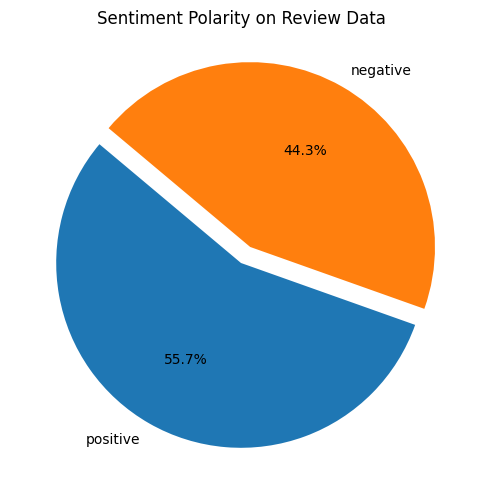

In [29]:
# Fungsi untuk menghitung skor sentimen berdasarkan lexicon
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    # Pastikan teks adalah string
    words = text.split()

    for word in words:
        if word in lexicon_positive:
            score += lexicon_positive[word]
        if word in lexicon_negative:
            score += lexicon_negative[word]

    # Menentukan label berdasarkan total skor
    if score >= 0: # Bisa disesuaikan > 0 jika ingin ada kategori netral
        return 'positive'
    else:
        return 'negative'

# Melakukan pelabelan pada kolom 'text_akhir' (hasil preprocessing terakhir kamu)
clean_df['label'] = clean_df['text_akhir'].apply(sentiment_analysis_lexicon_indonesia)

# --- BAGIAN VISUALISASI ---

import matplotlib.pyplot as plt

# Menghitung jumlah label
sentimen_counts = clean_df['label'].value_counts()
total_data = len(clean_df)

# Menampilkan ringkasan teks
print(f"Pada DataFrame clean_df, ada {sentimen_counts.get('negative', 0)} teks dengan polaritas negatif dan {sentimen_counts.get('positive', 0)} teks dengan polaritas positif.")
print(f"Dari hasil analisis, {(sentimen_counts.get('negative', 0)/total_data)*100:.1f}% dari teks memiliki polaritas negatif, sementara {(sentimen_counts.get('positive', 0)/total_data)*100:.1f}% memiliki polaritas positif.")

# Membuat Pie Chart
plt.figure(figsize=(6,6))
colors = ['#1f77b4', '#ff7f0e']
explode = (0, 0.1) if len(sentimen_counts) > 1 else (0,)

plt.pie(sentimen_counts,
        labels=sentimen_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=explode)

plt.title('Sentiment Polarity on Review Data')
plt.show()

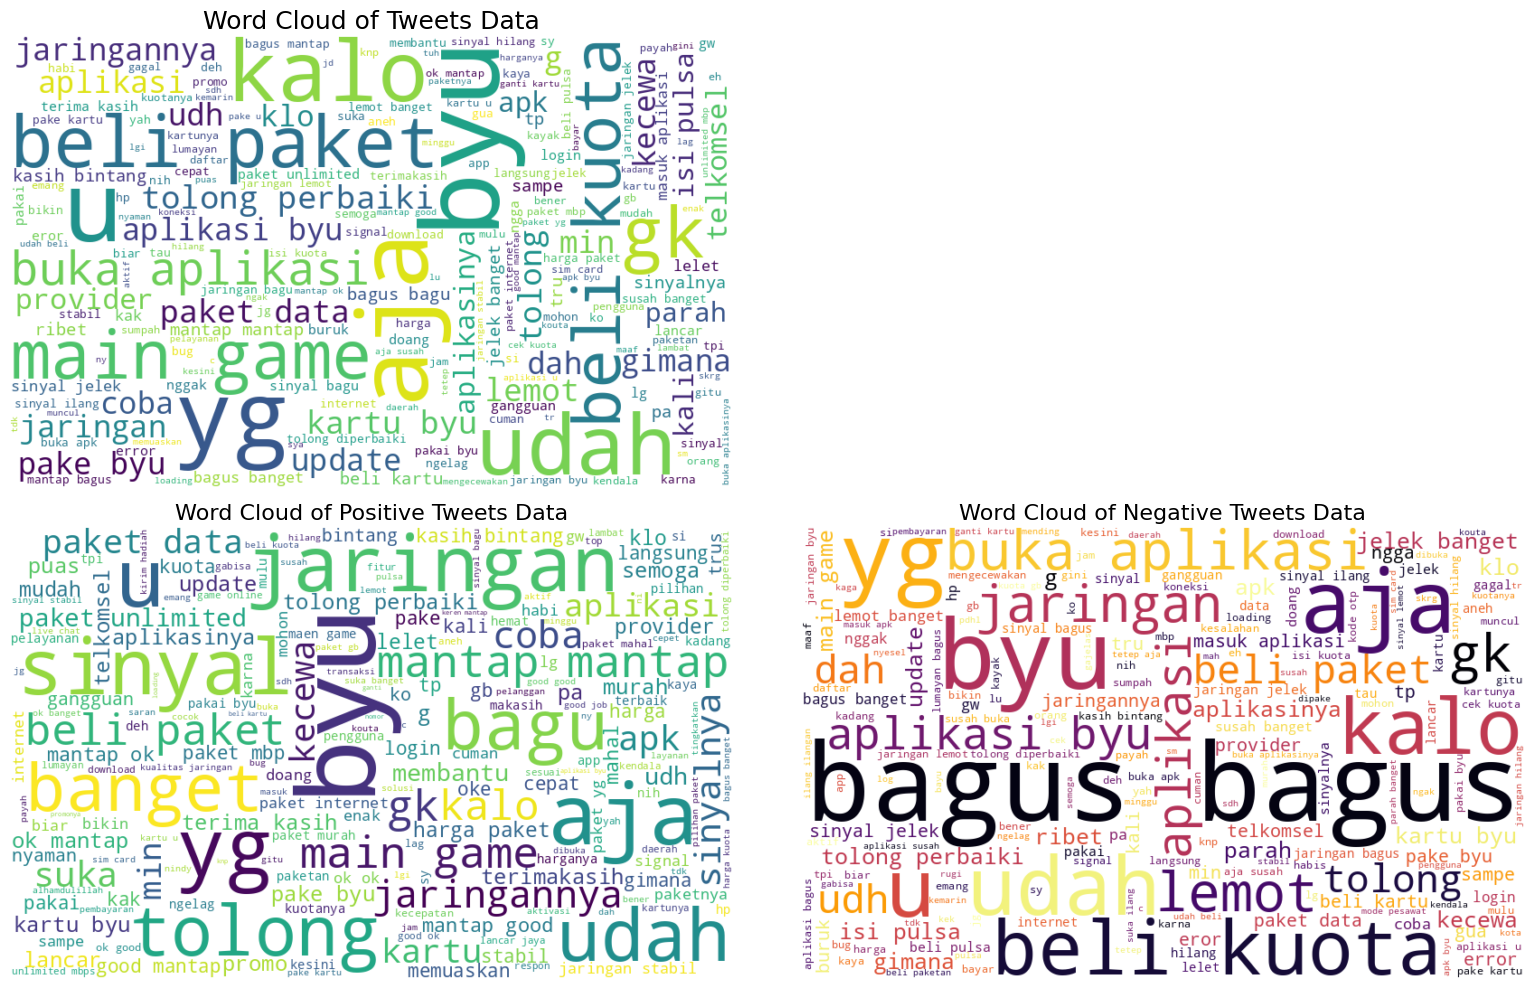

In [30]:
# 6. Eksplorasi Label menggunakan WorldCloud.

!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- 1. Persiapan Teks ---
# Menggabungkan semua teks menjadi satu string panjang berdasarkan kategori label
# Sesuaikan nama kolom jika berbeda (misalnya 'text_akhir' adalah hasil pembersihan terakhir)

all_text = ' '.join(clean_df['text_akhir'].astype(str))
positive_text = ' '.join(clean_df[clean_df['label'] == 'positive']['text_akhir'].astype(str))
negative_text = ' '.join(clean_df[clean_df['label'] == 'negative']['text_akhir'].astype(str))

# --- 2. Konfigurasi Visual ---
# Warna latar belakang dan ukuran gambar (bisa disesuaikan)
wc_config = {
    'background_color': 'white',
    'width': 800,
    'height': 500,
    'max_font_size': 120,
    'colormap': 'viridis' # Warna default sesuai gambar (viridis, plasma, inferno, dll.)
}

# --- 3. Membuat Tiga Visualisasi Word Cloud ---
# Visualisasi 1: Semua Data
wordcloud_all = WordCloud(**wc_config).generate(all_text)

# Visualisasi 2: Data Positif
wordcloud_pos = WordCloud(**wc_config).generate(positive_text)

# Visualisasi 3: Data Negatif (Gunakan colormap 'plasma' agar sedikit berbeda)
wc_config_neg = wc_config.copy()
wc_config_neg['colormap'] = 'inferno' # Gunakan colormap lain untuk negatif agar beda
wordcloud_neg = WordCloud(**wc_config_neg).generate(negative_text)

# --- 4. Tampilkan Visualisasi dalam Satu Plot Kotak ---
fig = plt.figure(figsize=(16, 10))

# Tata letak grid: Baris 1 (Semua), Baris 2 (Positif & Negatif)
# Gunakan fungsi `subplot()` atau `GridSpec` untuk kontrol yang lebih presisi

# Subplot 1: Word Cloud Utama (Semua Data)
plt.subplot(2, 2, 1)
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.title('Word Cloud of Tweets Data', fontsize=18)
plt.axis("off")

# Subplot 2: Word Cloud Positif
plt.subplot(2, 2, 3)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Word Cloud of Positive Tweets Data', fontsize=16)
plt.axis("off")

# Subplot 3: Word Cloud Negatif
plt.subplot(2, 2, 4)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Word Cloud of Negative Tweets Data', fontsize=16)
plt.axis("off")

plt.tight_layout() # Merapikan tata letak agar tidak tumpang tindih
plt.show()

In [33]:
# 7. Data Splitting dan Ekstraksi Fitur dengan TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [34]:
# 8. Modelling

# menggunakan Naive Bayes

from sklearn.naive_bayes import BernoulliNB

# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.7838351067101298
Naive Bayes - accuracy_test: 0.783227750784181


In [35]:
# menggunakan Random Forest

from sklearn.naive_bayes import BernoulliNB

# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.7838351067101298
Naive Bayes - accuracy_test: 0.783227750784181


In [37]:
# menggunakan logistic Regeression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.908573713020481
Logistic Regression - accuracy_test: 0.9094347745863829


In [38]:
# menggunakan decission tree

logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.908573713020481
Logistic Regression - accuracy_test: 0.9094347745863829
